### Graph API


In [24]:
import os
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from IPython.display import Image,display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

load_dotenv()

True

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
graph_builder = StateGraph(State)
graph_builder

In [4]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DDB6D19820>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DDB6EA3740>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# Node functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)
# adding node
graph_builder.add_node("llmchatbot", chatbot)
# adding edge
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

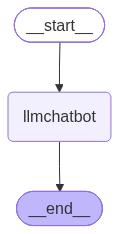

In [9]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages": "Hi"})

In [11]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='16f07242-2f2f-41fd-8c60-adaf6465680a'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.056095294, 'completion_tokens_details': None, 'prompt_time': 0.000954242, 'prompt_tokens_details': None, 'queue_time': 0.052055703, 'total_time': 0.057049536}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6bb-5bd3-7651-a7fb-a879869f5818-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"Hi! How are you?"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 41, 'total_tokens': 91, 'completion_time': 0.133025508, 'completion_tokens_details': None, 'prompt_time': 0.00128658, 'prompt_tokens_details': None, 'queue_time': 0.16764118, 'total_time': 0.134312088}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6bb-6201-7dc3-9e73-f8b7d0478a61-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 50, 'total_tokens': 91})]}}


In [14]:
for event in graph.stream({"messages":"Hi! How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going so far?


### Chatbot with tool

In [16]:
tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [37]:
def multiply(a:int, b:int) ->int:
    """Multiply a and b

    Args:
    a (int): first int
    b (int): second int

    Returns:
    int: output int

    """
    return a*b

In [38]:
tools = [tool, multiply]

In [39]:
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DDB6D19820>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DDB6EA3740>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'descr

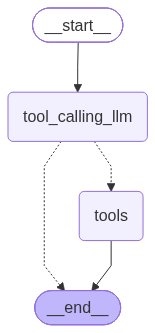

In [40]:
# State graph
# node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
                                # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
                                # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
                               tools_condition)
builder.add_edge("tools", END)

# compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [41]:
graph.invoke({"messages": "What is the recent ai news?"})

{'messages': [HumanMessage(content='What is the recent ai news?', additional_kwargs={}, response_metadata={}, id='a9ad100a-0230-4d75-be94-c25dbf867fb7'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ze6kdn0cf', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1752, 'total_tokens': 1783, 'completion_time': 0.084835515, 'completion_tokens_details': None, 'prompt_time': 0.086846769, 'prompt_tokens_details': None, 'queue_time': 0.162268007, 'total_time': 0.171682284}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff6e1-5b07-7c90-91a8-e5000ef9b283-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'time_range': 'day', 'topic': '

In [42]:
response = graph.invoke({"messages": "What is the recent ai news?"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/technology/ai/articles/latest-news-ai-chips-advanced-113731294.html", "title": "Latest News In AI Chips - Advanced Chip Packaging Sparks Market Growth Shift", "content": "Recent developments in the AI chip market highlight a significant shift towards advanced chip packaging technologies. According to BCC Research, this market is expected to grow substantially, from $38.6 billion in 2024 to $87.6 billion by 2030, driven by increasing demand for AI and high-performance computing applications. This growth is largely influenced by the need for improved data throughput, reduced latency, and greater interconnect density, surpassing what traditional packaging can [...] In other trading, Jentech Precision Industrial was a standout up 10% and closing at NT$4,470.00. In the meantime, SiTime trailed, down 3.3% to end the day at $667.10.\\n\\nRiding the AI and 5G w

In [43]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (0xdhd2k20)
 Call ID: 0xdhd2k20
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/technology/ai/articles/latest-news-ai-chips-advanced-113731294.html", "title": "Latest News In AI Chips - Advanced Chip Packaging Sparks Market Growth Shift", "content": "Recent developments in the AI chip market highlight a significant shift towards advanced chip packaging technologies. According to BCC Research, this market is expected to grow substantially, from $38.6 billion in 2024 to $87.6 billion by 2030, driven by increasing demand

In [44]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (gs714j63w)
 Call ID: gs714j63w
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [45]:
response=graph.invoke({"messages":"What is 5 multiplied by 2 and the multiply 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and the multiply 10
================================== Ai Message ==================================
Tool Calls:
  multiply (ctfwqhh2m)
 Call ID: ctfwqhh2m
  Args:
    a: 5
    b: 2
  multiply (zcgq1x4sz)
 Call ID: zcgq1x4sz
  Args:
    a: 10
    b: 2
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

20


In [46]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (by412fp9c)
 Call ID: by412fp9c
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (tsahtxv8r)
 Call ID: tsahtxv8r
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/technology/ai/articles/latest-news-ai-chips-advanced-113731294.html", "title": "Latest News In AI Chips - Advanced Chip Packaging Sparks Market Growth Shift", "content": "Recent developments in the AI chip market highlight a significant shift towards advanced chip packaging technologies. According to BCC Research, this market is expected to g